# Measure-Group Distribution
Categorises all 1,651 agents into six mutually exclusive groups based on
which REF/REN measures they performed.

Group distribution:
  Nur thermische Sanierung                 50  (3.0%)
  Nur Heizungstausch                      154  (9.3%)
  Sanierung + Heizungstausch              206  (12.5%)
  Nur erneuerbare Energie                 130  (7.9%)
  Sanierung + Tausch + Neubau             673  (40.8%)
  Keine Maßnahmen                         438  (26.5%)
  Total: 1651


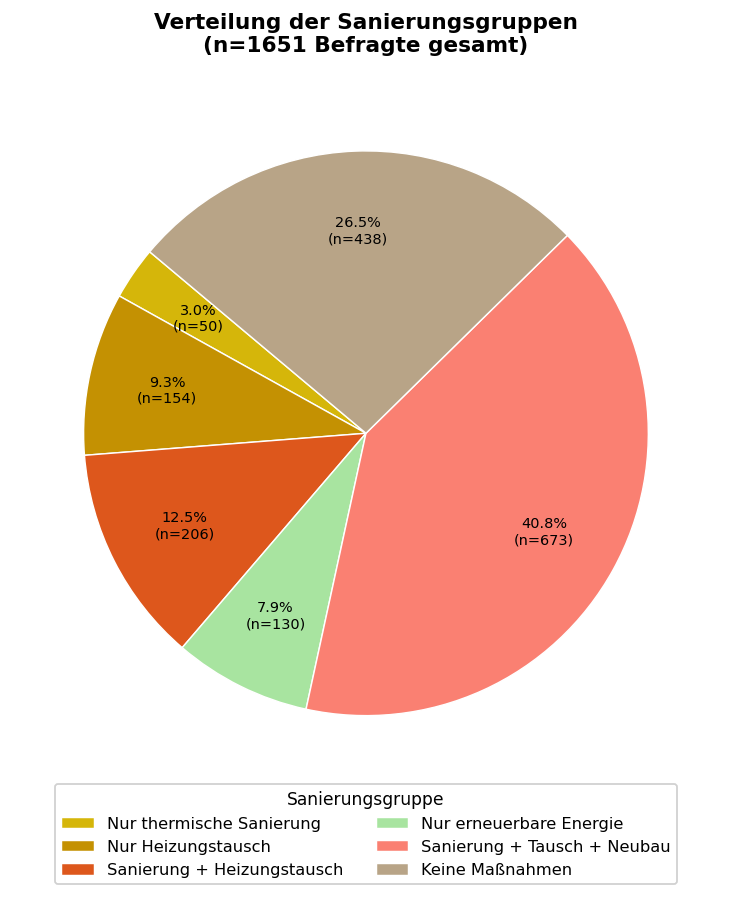

In [1]:
import json
import matplotlib.pyplot as plt

# ── Load ──────────────────────────────────────────────────────────────────────
with open("../data/processed/survey_v1.1.json") as f:
    data = json.load(f)

REF14 = ["REF_1", "REF_2", "REF_3", "REF_4"]
REF5  = "REF_5"
REN   = ["REN_1", "REN_2", "REN_3", "REN_4", "REN_5", "REN_6", "REN_7"]

def has(r, fields):
    return any(str(r.get(f, "0")) == "1" for f in fields)

# ── Classify ──────────────────────────────────────────────────────────────────
groups = {
    "Nur thermische\nSanierung":     0,
    "Nur\nHeizungstausch":           0,
    "Sanierung +\nHeizungstausch":   0,
    "Nur erneuerbare\nEnergie":      0,
    "Sanierung +\nTausch + Neubau":  0,
    "Keine\nMaßnahmen":              0,
}

for r in data:
    h14  = has(r, REF14)
    h5   = str(r.get(REF5, "0")) == "1"
    hren = has(r, REN)

    if   h14 and not h5 and not hren:
        groups["Nur thermische\nSanierung"]    += 1
    elif not h14 and h5 and not hren:
        groups["Nur\nHeizungstausch"]           += 1
    elif h14 and h5 and not hren:
        groups["Sanierung +\nHeizungstausch"]   += 1
    elif not h14 and not h5 and hren:
        groups["Nur erneuerbare\nEnergie"]      += 1
    elif not h14 and not h5 and not hren:
        groups["Keine\nMaßnahmen"]              += 1
    else:
        groups["Sanierung +\nTausch + Neubau"]  += 1

total  = sum(groups.values())
labels = list(groups.keys())
values = list(groups.values())

print("Group distribution:")
for lbl, v in zip(labels, values):
    flat = lbl.replace("\n", " ")
    print(f"  {flat:38s} {v:4d}  ({v/total*100:.1f}%)")
print(f"  Total: {total}")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":       130,
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
})

colors = ["#D5B60A", "#C49102", "#DD571C", "#A8E4A0", "#FA8072", "#B8A487"]

fig, ax = plt.subplots(figsize=(8, 7))

wedges, texts, autotexts = ax.pie(
    values,
    labels=None,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%\n(n={round(p*total/100)})",
    pctdistance=0.72,
    startangle=140,
    wedgeprops={"linewidth": 0.8, "edgecolor": "white"},
)

for at in autotexts:
    at.set_fontsize(8)

ax.legend(
    wedges,
    [lbl.replace("\n", " ") for lbl in labels],
    title="Sanierungsgruppe",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    fontsize=9,
    title_fontsize=9.5,
    framealpha=0.9,
)

ax.set_title(
    f"Verteilung der Sanierungsgruppen\n(n={total} Befragte gesamt)",
    pad=16,
)

plt.tight_layout()
plt.show()